<a href="https://colab.research.google.com/github/KaiIkuta/MIDSSAR/blob/main/MIDSSAR_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls -l /content/drive/MyDrive/MIDSSAR/260425/20260425H/

total 13490
-rw------- 1 root root 394131 Jul 15 05:16 EK_Dra_dH_001_x.dat
-rw------- 1 root root 394174 Jul 15 05:16 EK_Dra_dH_002_x.dat
-rw------- 1 root root 394323 Jul 15 05:16 EK_Dra_dH_003_x.dat
-rw------- 1 root root 394433 Jul 15 05:16 EK_Dra_dH_004_x.dat
-rw------- 1 root root 394237 Jul 15 05:16 EK_Dra_dH_005_x.dat
-rw------- 1 root root 394705 Jul 15 05:16 EK_Dra_dH_006_x.dat
-rw------- 1 root root 394329 Jul 15 05:16 EK_Dra_dH_007_x.dat
-rw------- 1 root root 394478 Jul 15 05:16 EK_Dra_dH_008_x.dat
-rw------- 1 root root 396476 Jul 15 05:16 EK_Dra_dH_009_x.dat
-rw------- 1 root root 395610 Jul 15 05:16 EK_Dra_dH_010_x.dat
-rw------- 1 root root 393111 Jul 15 05:16 EK_Dra_dH_011_x.dat
-rw------- 1 root root 394024 Jul 15 05:16 EK_Dra_dH_012_x.dat
-rw------- 1 root root 394291 Jul 15 05:16 EK_Dra_dH_013_x.dat
-rw------- 1 root root 394166 Jul 15 05:16 EK_Dra_dH_014_x.dat
-rw------- 1 root root 394219 Jul 15 05:16 EK_Dra_dH_015_x.dat
-rw------- 1 root root 394182 Jul 15 05:16 

In [3]:
%cd /content/drive/MyDrive/MIDSSAR/260425/20260425H

/content/drive/MyDrive/MIDSSAR/260425/20260425H


In [4]:
import glob
import os
import pandas as pd


file_pattern = '/content/drive/MyDrive/MIDSSAR/260425/20260425H/EK_Dra_dH_*_x.dat'
file_list = sorted(glob.glob(file_pattern))


dataframes = {}
for file_path in file_list:
    filename = os.path.basename(file_path)

    df = pd.read_csv(file_path, sep=r'\s+', comment='#', header=None)
    dataframes[filename] = df
    print(f"Read {filename} (Shape: {df.shape})")


if len(file_list) > 0:
    first_file = os.path.basename(file_list[0])
    display(dataframes[first_file].head())

Read EK_Dra_dH_001_x.dat (Shape: (4848, 10))
Read EK_Dra_dH_002_x.dat (Shape: (4848, 10))
Read EK_Dra_dH_003_x.dat (Shape: (4848, 10))
Read EK_Dra_dH_004_x.dat (Shape: (4848, 10))
Read EK_Dra_dH_005_x.dat (Shape: (4848, 10))
Read EK_Dra_dH_006_x.dat (Shape: (4848, 10))
Read EK_Dra_dH_007_x.dat (Shape: (4848, 10))
Read EK_Dra_dH_008_x.dat (Shape: (4848, 10))
Read EK_Dra_dH_009_x.dat (Shape: (4848, 10))
Read EK_Dra_dH_010_x.dat (Shape: (4848, 10))
Read EK_Dra_dH_011_x.dat (Shape: (4848, 10))
Read EK_Dra_dH_012_x.dat (Shape: (4848, 10))
Read EK_Dra_dH_013_x.dat (Shape: (4848, 10))
Read EK_Dra_dH_014_x.dat (Shape: (4848, 10))
Read EK_Dra_dH_015_x.dat (Shape: (4848, 10))
Read EK_Dra_dH_016_x.dat (Shape: (4848, 10))
Read EK_Dra_dH_017_x.dat (Shape: (4848, 10))
Read EK_Dra_dH_018_x.dat (Shape: (4848, 10))
Read EK_Dra_dH_019_x.dat (Shape: (4848, 10))
Read EK_Dra_dH_020_x.dat (Shape: (4848, 10))
Read EK_Dra_dH_021_x.dat (Shape: (4848, 10))
Read EK_Dra_dH_022_x.dat (Shape: (4848, 10))
Read EK_Dr

,0,1,2,3,4,5,6,7,8,9
0,668.644,668.829,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0
1,668.638,668.823,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0
2,668.632,668.817,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0
3,668.626,668.811,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0
4,668.620,668.805,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0


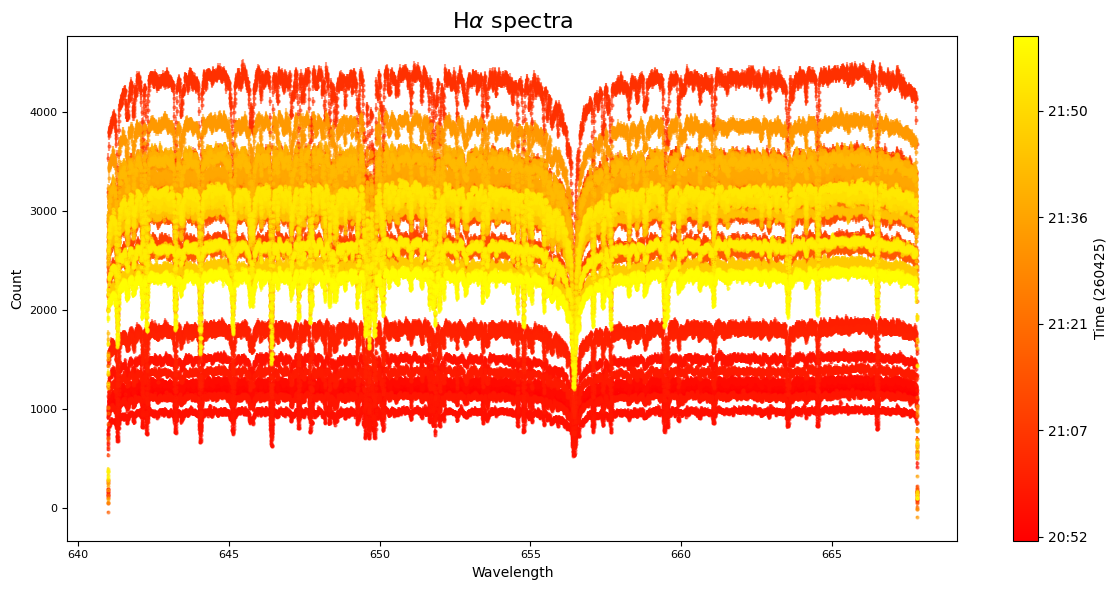

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
import matplotlib.cm as cm

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

first_df = list(dataframes.values())[0]
wavelengths = first_df[1].values


log_file = '/content/drive/MyDrive/MIDSSAR/260425/20260425H/EK_Dra_H.log'
log_df = pd.read_csv(log_file, sep=r'\s+', header=None)
time_strs = log_df[0].astype(str) + ' ' + log_df[1].astype(str)

times = pd.to_datetime(time_strs.iloc[:len(dataframes)])


time_nums = mdates.date2num(times)
norm = plt.Normalize(vmin=time_nums.min(), vmax=time_nums.max())
cmap = cm.autumn

for i, (filename, df) in enumerate(dataframes.items()):
    Y = df[3].values
    Yerr = df[4].values
    color = cmap(norm(time_nums[i]))
    ax.errorbar(wavelengths, Y, yerr=Yerr, fmt='o', markersize=2, color=color, alpha=0.5)

ax.set_xlabel('Wavelength', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
ax.set_title(r'H$\alpha$ spectra', fontsize=16)
#ax.set_xlim([655, 658])
ax.tick_params(axis='both', which='major', labelsize=8)


sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
cbar.set_label('Time (260425)', fontsize=10)

plt.tight_layout()
plt.show()


EK_Dra_dH_001_x.dat
EK_Dra_dH_002_x.dat
EK_Dra_dH_003_x.dat
EK_Dra_dH_004_x.dat
EK_Dra_dH_005_x.dat
EK_Dra_dH_006_x.dat
EK_Dra_dH_007_x.dat
EK_Dra_dH_008_x.dat
EK_Dra_dH_009_x.dat
EK_Dra_dH_010_x.dat
EK_Dra_dH_011_x.dat
EK_Dra_dH_012_x.dat
EK_Dra_dH_013_x.dat
EK_Dra_dH_014_x.dat
EK_Dra_dH_015_x.dat
EK_Dra_dH_016_x.dat
EK_Dra_dH_017_x.dat
EK_Dra_dH_018_x.dat
EK_Dra_dH_019_x.dat
EK_Dra_dH_020_x.dat
EK_Dra_dH_021_x.dat
EK_Dra_dH_022_x.dat
EK_Dra_dH_023_x.dat
EK_Dra_dH_024_x.dat
EK_Dra_dH_025_x.dat
EK_Dra_dH_026_x.dat
EK_Dra_dH_027_x.dat
EK_Dra_dH_028_x.dat
EK_Dra_dH_029_x.dat
EK_Dra_dH_030_x.dat
EK_Dra_dH_031_x.dat
EK_Dra_dH_032_x.dat
EK_Dra_dH_033_x.dat
EK_Dra_dH_034_x.dat
EK_Dra_dH_035_x.dat
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


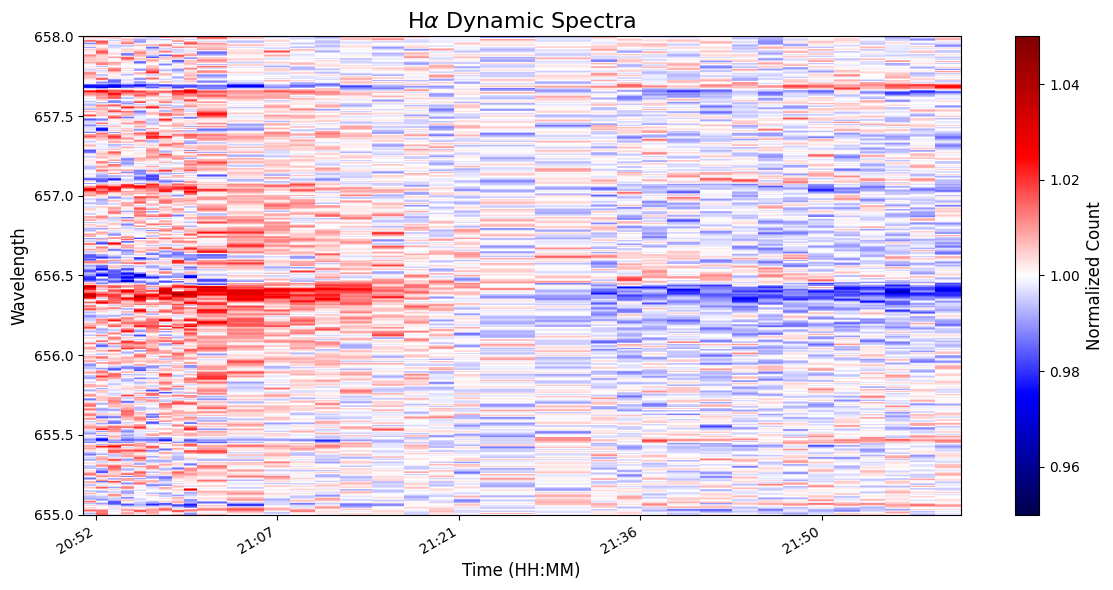

In [6]:


spectra_list = []
for filename in sorted(dataframes.keys()):
    print(filename)
    spectra_list.append(dataframes[filename][8].values)

spectra_matrix = np.array(spectra_list).T
print(spectra_matrix)

fig, ax = plt.subplots(figsize=(12, 6))

X, Y = np.meshgrid(mdates.date2num(times), wavelengths)


im = ax.pcolormesh(X, Y, spectra_matrix, cmap="seismic", shading='auto', vmin=0.95, vmax=1.05)

ax.set_xlabel('Time (HH:MM)', fontsize=12)
ax.set_ylabel('Wavelength', fontsize=12)
ax.set_title(r'H$\alpha$ Dynamic Spectra', fontsize=16)
ax.set_ylim([655, 658])


ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
fig.autofmt_xdate()

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Normalized Count', fontsize=12)

plt.tight_layout()
plt.show()

In [7]:
%cd /content/drive/MyDrive/MIDSSAR/260425/20260425C

/content/drive/MyDrive/MIDSSAR/260425/20260425C


In [8]:

file_pattern = '/content/drive/MyDrive/MIDSSAR/260425/20260425C/EK_Dra_dC_*_x.dat'
file_list = sorted(glob.glob(file_pattern))


dataframes = {}
for file_path in file_list:
    filename = os.path.basename(file_path)
    df = pd.read_csv(file_path, sep=r'\s+', comment='#', header=None)
    dataframes[filename] = df
    print(f"Read {filename} (Shape: {df.shape})")


if len(file_list) > 0:
    first_file = os.path.basename(file_list[0])
    display(dataframes[first_file].head())


Read EK_Dra_dC_001_x.dat (Shape: (4848, 10))
Read EK_Dra_dC_002_x.dat (Shape: (4848, 10))
Read EK_Dra_dC_003_x.dat (Shape: (4848, 10))
Read EK_Dra_dC_004_x.dat (Shape: (4848, 10))
Read EK_Dra_dC_005_x.dat (Shape: (4848, 10))
Read EK_Dra_dC_006_x.dat (Shape: (4848, 10))
Read EK_Dra_dC_007_x.dat (Shape: (4848, 10))
Read EK_Dra_dC_008_x.dat (Shape: (4848, 10))
Read EK_Dra_dC_009_x.dat (Shape: (4848, 10))
Read EK_Dra_dC_010_x.dat (Shape: (4848, 10))


,0,1,2,3,4,5,6,7,8,9
0,382.480,382.589,8055.850,2696.560,50.2607,1464.170,0.982573,0.006130,1.22853,0.007665
1,382.485,382.594,654.699,318.589,24.1377,109.864,0.862889,0.031813,1.07889,0.039777
2,382.490,382.599,650.320,311.878,24.0356,110.681,0.853042,0.031528,1.06658,0.039420
3,382.495,382.604,642.685,297.724,23.9646,112.075,0.852589,0.031792,1.06601,0.039750
4,382.500,382.609,630.689,297.182,23.9069,108.668,0.854029,0.032373,1.06781,0.040476


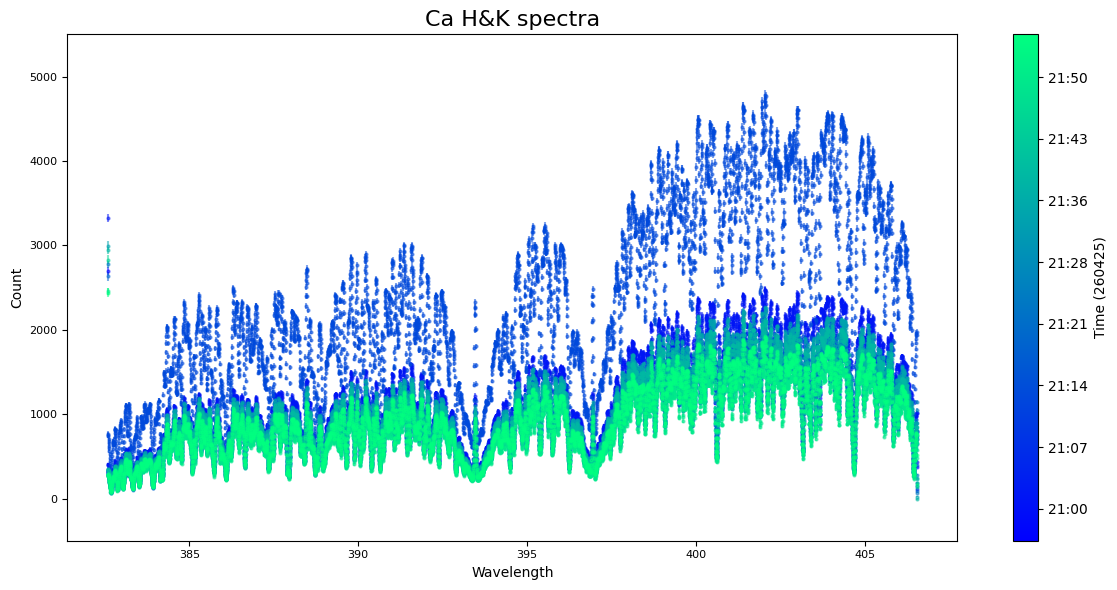

In [9]:


fig, ax = plt.subplots(1, 1, figsize=(12, 6))


first_df = list(dataframes.values())[0]
wavelengths = first_df[1].values

log_file = '/content/drive/MyDrive/MIDSSAR/260425/20260425C/EK_Dra_C.log'

log_df = pd.read_csv(log_file, sep=r'\s+', header=None)

time_strs = log_df[0].astype(str) + ' ' + log_df[1].astype(str)

times = pd.to_datetime(time_strs.iloc[:len(dataframes)])

time_nums = mdates.date2num(times)
norm = plt.Normalize(vmin=time_nums.min(), vmax=time_nums.max())
cmap = cm.winter

for i, (filename, df) in enumerate(dataframes.items()):
    Y = df[3].values
    Yerr = df[4].values
    color = cmap(norm(time_nums[i]))

    ax.errorbar(wavelengths, Y, yerr=Yerr, fmt='o', markersize=2, color=color, alpha=0.5)

ax.set_xlabel('Wavelength', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
ax.set_title(r'Ca H&K spectra', fontsize=16)
ax.set_ylim([-500,5500])
ax.tick_params(axis='both', which='major', labelsize=8)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
cbar.set_label('Time (260425)', fontsize=10)

plt.tight_layout()
plt.show()


EK_Dra_dC_001_x.dat
EK_Dra_dC_002_x.dat
EK_Dra_dC_003_x.dat
EK_Dra_dC_004_x.dat
EK_Dra_dC_005_x.dat
EK_Dra_dC_006_x.dat
EK_Dra_dC_007_x.dat
EK_Dra_dC_008_x.dat
EK_Dra_dC_009_x.dat
EK_Dra_dC_010_x.dat
[[1.22853  0.768357 0.98311  ... 1.23106  0.823779 1.24131 ]
 [1.07889  0.934819 0.990352 ... 1.04326  0.940742 1.09183 ]
 [1.06658  0.945853 1.01033  ... 1.027    0.950766 1.08371 ]
 ...
 [0.       0.       0.       ... 0.       0.       0.      ]
 [0.       0.       0.       ... 0.       0.       0.      ]
 [0.       0.       0.       ... 0.       0.       0.      ]]


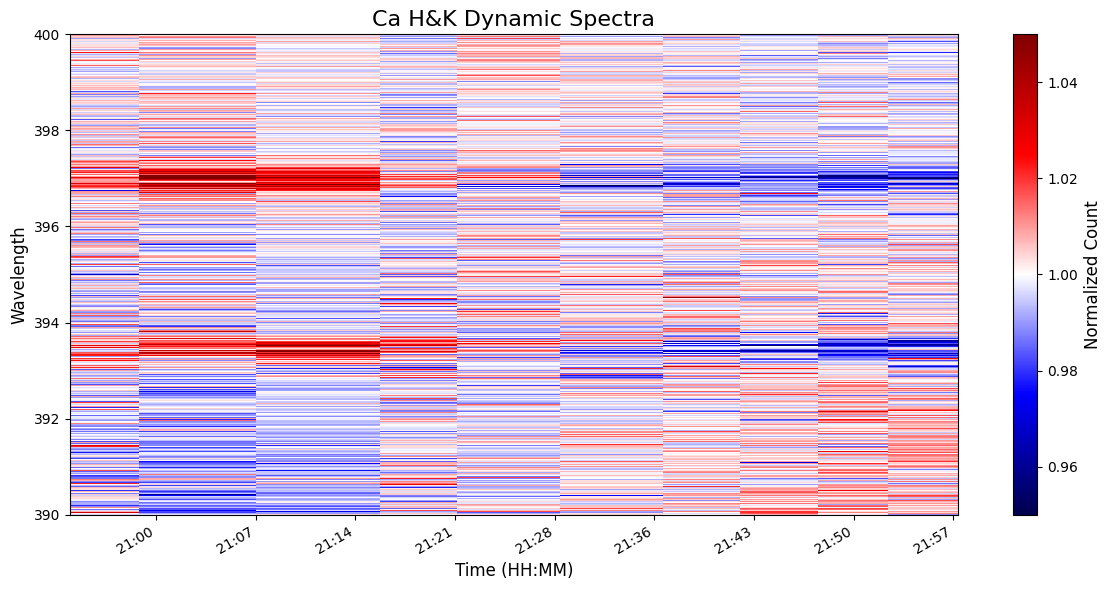

In [10]:


spectra_list = []
for filename in sorted(dataframes.keys()):

    print(filename)
    spectra_list.append(dataframes[filename][8].values)


spectra_matrix = np.array(spectra_list).T
print(spectra_matrix)

fig, ax = plt.subplots(figsize=(12, 6))

X, Y = np.meshgrid(mdates.date2num(times), wavelengths)

im = ax.pcolormesh(X, Y, spectra_matrix, cmap="seismic", shading='auto', vmin=0.95, vmax=1.05)

ax.set_xlabel('Time (HH:MM)', fontsize=12)
ax.set_ylabel('Wavelength', fontsize=12)
ax.set_title(r'Ca H&K Dynamic Spectra', fontsize=16)
ax.set_ylim([390, 400])

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
fig.autofmt_xdate()

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Normalized Count', fontsize=12)

plt.tight_layout()
plt.show()